In [1]:
!pip install gymnasium torch matplotlib

🚀 Training started on cuda...
Episode 100/3000 | Epsilon: 0.819 | Success Rate (Last 100): 0.03
Episode 200/3000 | Epsilon: 0.670 | Success Rate (Last 100): 0.07
Episode 300/3000 | Epsilon: 0.548 | Success Rate (Last 100): 0.13
Episode 400/3000 | Epsilon: 0.449 | Success Rate (Last 100): 0.38
Episode 500/3000 | Epsilon: 0.368 | Success Rate (Last 100): 0.47
Episode 600/3000 | Epsilon: 0.301 | Success Rate (Last 100): 0.68
Episode 700/3000 | Epsilon: 0.246 | Success Rate (Last 100): 0.65
Episode 800/3000 | Epsilon: 0.202 | Success Rate (Last 100): 0.79
Episode 900/3000 | Epsilon: 0.165 | Success Rate (Last 100): 0.75
Episode 1000/3000 | Epsilon: 0.135 | Success Rate (Last 100): 0.84
Episode 1100/3000 | Epsilon: 0.111 | Success Rate (Last 100): 0.88
Episode 1200/3000 | Epsilon: 0.091 | Success Rate (Last 100): 0.87
Episode 1300/3000 | Epsilon: 0.074 | Success Rate (Last 100): 0.92
Episode 1400/3000 | Epsilon: 0.061 | Success Rate (Last 100): 0.95
Episode 1500/3000 | Epsilon: 0.050 | Succ

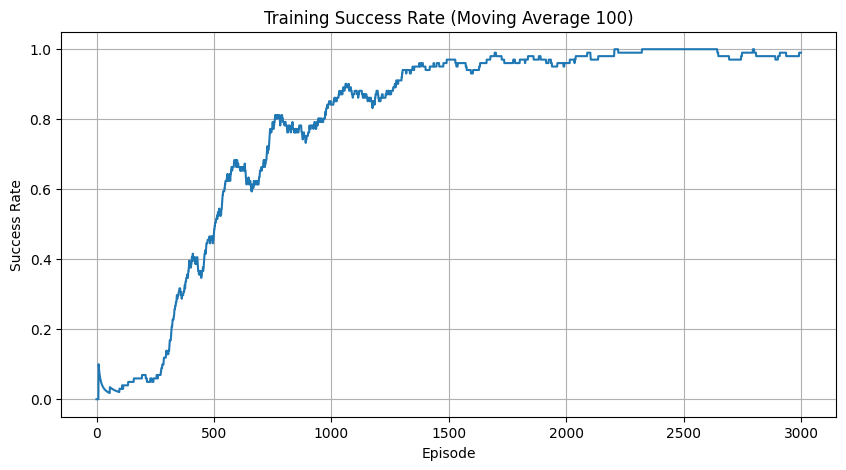


🎬 Demonstrating Final Agent:

SFFF
FHFH
FFFH
HFFG

  (Right)
SFFF
FHFH
FFFH
HFFG

  (Right)
SFFF
FHFH
FFFH
HFFG

  (Down)
SFFF
FHFH
FFFH
HFFG

  (Down)
SFFF
FHFH
FFFH
HFFG

  (Down)
SFFF
FHFH
FFFH
HFFG

  (Right)
SFFF
FHFH
FFFH
HFFG

🏆 Reached the Goal!


In [14]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import deque, namedtuple

# --- 1. Define Classes (Global scope for pickle/serialization compatibility) ---

class DQN(nn.Module):
    """
    Deep Q-Network with one hidden layer.
    Structure: Input -> Linear(32) -> ReLU -> Linear(Output)
    """
    def __init__(self, n_states, n_actions):
        super(DQN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(n_states, 32),  # Hidden layer with 32 neurons
            nn.ReLU(),                # Activation function
            nn.Linear(32, n_actions)  # Output layer
        )

    def forward(self, x):
        return self.net(x)

Experience = namedtuple('Experience', ('state', 'action', 'reward', 'next_state', 'done'))

class ReplayBuffer:
    """
    Buffer to store and sample experience tuples.
    """
    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.memory.append(Experience(state, action, reward, next_state, done))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

# --- 2. Main Training Function ---

def train_frozenlake_dqn(episodes=3000, batch_size=64, learning_rate=0.001):
    """
    Main function to setup environment, train the agent, and visualize results.
    """
    # Hyperparameters
    GAMMA = 0.99
    EPSILON = 1.0
    EPSILON_DECAY = 0.998
    MIN_EPSILON = 0.01
    TARGET_UPDATE = 50      # Update target network every 50 steps
    REPLAY_CAPACITY = 10000
    MIN_BUFFER_SIZE = 500   # Start training after 500 experiences

    # Environment Setup
    # is_slippery=False for deterministic environment (Standard FrozenLake)
    env = gym.make('FrozenLake-v1', is_slippery=False, render_mode=None)
    n_states = env.observation_space.n
    n_actions = env.action_space.n

    # Device configuration (use GPU if available, though CPU is fine for this size)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Initialize Networks
    policy_net = DQN(n_states, n_actions).to(device)
    target_net = DQN(n_states, n_actions).to(device)

    # Sync weights
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(policy_net.parameters(), lr=learning_rate)
    loss_fn = nn.SmoothL1Loss() # Huber Loss for stability
    buffer = ReplayBuffer(REPLAY_CAPACITY)

    # Helper: State to Tensor
    def state_to_tensor(state):
        x = torch.zeros(n_states).to(device)
        x[state] = 1.0
        return x.unsqueeze(0)

    # Helper: Optimization Step
    def optimize_model():
        if len(buffer) < MIN_BUFFER_SIZE:
            return

        experiences = buffer.sample(batch_size)

        batch = Experience(*zip(*experiences))

        state_batch = torch.cat([state_to_tensor(s) for s in batch.state])
        action_batch = torch.tensor(batch.action).unsqueeze(1).to(device)
        reward_batch = torch.tensor(batch.reward).float().unsqueeze(1).to(device)
        next_state_batch = torch.cat([state_to_tensor(s) for s in batch.next_state])
        done_batch = torch.tensor(batch.done).float().unsqueeze(1).to(device)

        # Q(s, a) from policy net
        state_action_values = policy_net(state_batch).gather(1, action_batch)

        # V(s') = max_a Q(s', a) from target net
        with torch.no_grad():
            next_state_values = target_net(next_state_batch).max(1)[0].unsqueeze(1)

        # Compute expected Q values
        expected_state_action_values = reward_batch + (GAMMA * next_state_values * (1 - done_batch))

        # Compute Loss
        loss = loss_fn(state_action_values, expected_state_action_values)

        # Optimize
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(policy_net.parameters(), 1.0) # Gradient clipping
        optimizer.step()

    # --- Training Loop ---
    print(f"🚀 Training started on {device}...")
    scores = []
    steps_total = 0

    for episode in range(episodes):
        state, _ = env.reset()
        done = False

        while not done:
            # Epsilon-Greedy Action Selection
            if random.random() < EPSILON:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    # t.max(1) returns (values, indices), we want indices
                    action = policy_net(state_to_tensor(state)).max(1)[1].item()

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # Store experience
            # Note: We do NOT use manual penalty (-0.1) here.
            # 0 for step, 0 for hole, 1 for goal is cleaner for DQN.
            buffer.push(state, action, reward, next_state, done)

            # Train
            optimize_model()

            # Update Target Network
            steps_total += 1
            if steps_total % TARGET_UPDATE == 0:
                target_net.load_state_dict(policy_net.state_dict())

            state = next_state

        scores.append(reward)

        # Decay Epsilon
        if EPSILON > MIN_EPSILON:
            EPSILON *= EPSILON_DECAY

        # Logging
        if (episode + 1) % 100 == 0:
            avg_score = np.mean(scores[-100:])
            print(f"Episode {episode+1}/{episodes} | Epsilon: {EPSILON:.3f} | Success Rate (Last 100): {avg_score:.2f}")

    print("✅ Training Complete.")
    env.close()

    # --- Visualization ---
    moving_avg = [np.mean(scores[max(0, i-100):i+1]) for i in range(len(scores))]
    plt.figure(figsize=(10, 5))
    plt.plot(moving_avg)
    plt.title('Training Success Rate (Moving Average 100)')
    plt.xlabel('Episode')
    plt.ylabel('Success Rate')
    plt.grid(True)
    plt.show()

    # --- Final Test ---
    print("\n🎬 Demonstrating Final Agent:")
    test_env = gym.make('FrozenLake-v1', is_slippery=False, render_mode='ansi')
    state, _ = test_env.reset()
    print(test_env.render())
    done = False

    steps = 0
    while not done and steps < 20:
        with torch.no_grad():
             action = policy_net(state_to_tensor(state)).max(1)[1].item()
        state, reward, term, trunc, _ = test_env.step(action)
        done = term or trunc
        print(test_env.render())
        steps += 1

    if reward == 1.0:
        print("🏆 Reached the Goal!")
    else:
        print("💀 Fell in a hole.")
    test_env.close()

# --- 3. Execute ---
if __name__ == "__main__":
    # Call the function to start everything
    train_frozenlake_dqn()